<a href="https://colab.research.google.com/github/rodrigologin0-cpu/Rodrigo-de-Souza-Lima/blob/main/FULL_NARX_x_LASSO_x_NSGA_II_x_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# COMPARAÇÃO: FULL NARX x LASSO x NSGA-II x LSTM
# Dados em segundos -> minutos
# Horizonte: 1 a 10 minutos à frente
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import warnings

from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings("ignore")

np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [41]:

# ============================================================
# CONFIGURAÇÕES
# ============================================================

ARQUIVO = "/content/Dataset.xlsx"

HORIZONS = list(range(1, 11))   # 1 a 10 minutos à frente
LAG = 3
DEGREE = 2
ACCEPTABLE_ERROR = 10.0

# NSGA-II
POP_SIZE = 20
GENERATIONS = 20
MUTATION_RATE = 0.08
INITIAL_PROB = 0.08
MAX_TERMS = 14

# LSTM
LSTM_LOOKBACK = 10
LSTM_UNITS = 10
LSTM_EPOCHS = 20
LSTM_BATCH_SIZE = 32

In [42]:
# ============================================================
# 1. LEITURA DOS DADOS E REAMOSTRAGEM
# ============================================================

df_sec = pd.read_excel(ARQUIVO).dropna().reset_index(drop=True)
df_sec = df_sec.select_dtypes(include=[np.number])

# Conversão segundos -> minutos
df_min = (
    df_sec
    .groupby(df_sec.index // 60)
    .mean(numeric_only=True)
    .reset_index(drop=True)
)

col_y = df_min.columns[0]
cols_u = list(df_min.columns[1:])

print("Dataset original:", df_sec.shape)
print("Dataset em minutos:", df_min.shape)
print("Variável alvo:", col_y)
print("Entradas:", cols_u)


Dataset original: (43201, 7)
Dataset em minutos: (721, 7)
Variável alvo: y
Entradas: ['u1', 'u2', 'u3', 'u4', 'u5', 'u6']


In [43]:

# ============================================================
# 2. FUNÇÕES AUXILIARES
# ============================================================

def calc_metrics(y_true, y_pred):
    erro = y_true - y_pred

    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "ROB": np.std(erro),
        "PCT_10C": 100 * np.mean(np.abs(erro) <= ACCEPTABLE_ERROR)
    }


def build_narx_dataset(H):
    data = pd.DataFrame(index=df_min.index)

    data[f"{col_y}_t"] = df_min[col_y]

    for i in range(1, LAG + 1):
        data[f"{col_y}_t-{i}"] = df_min[col_y].shift(i)

    for c in cols_u:
        data[f"{c}_t"] = df_min[c]

        for i in range(1, LAG + 1):
            data[f"{c}_t-{i}"] = df_min[c].shift(i)

    data["target"] = df_min[col_y].shift(-H)

    data = data.dropna().reset_index(drop=True)

    X = data.drop(columns=["target"])
    y = data["target"].values

    split = int(0.7 * len(X))

    X_train_base = X.iloc[:split]
    X_test_base = X.iloc[split:]

    y_train = y[:split]
    y_test = y[split:]

    scaler = StandardScaler()

    X_train_s = scaler.fit_transform(X_train_base)
    X_test_s = scaler.transform(X_test_base)

    poly = PolynomialFeatures(degree=DEGREE, include_bias=False)

    X_train_p = poly.fit_transform(X_train_s)
    X_test_p = poly.transform(X_test_s)

    names = poly.get_feature_names_out(X.columns)

    return X_train_p, X_test_p, y_train, y_test, names


def term_cost(mask, names):
    cost = 0

    for i, active in enumerate(mask):
        if active:
            term = str(names[i])

            if (" " in term) or ("^" in term):
                cost += 4
            else:
                cost += 2

    return cost


def full_cost(names):
    return sum(
        4 if (" " in str(t) or "^" in str(t)) else 2
        for t in names
    )


def evaluate_mask(mask, Xtr, Xte, ytr, yte, names):
    mask = mask.copy()

    if mask.sum() == 0:
        mask[np.random.randint(len(mask))] = True

    while mask.sum() > MAX_TERMS:
        idx = np.where(mask)[0]
        mask[np.random.choice(idx)] = False

    model = LinearRegression()
    model.fit(Xtr[:, mask], ytr)

    pred = model.predict(Xte[:, mask])

    m = calc_metrics(yte, pred)

    return {
        "mask": mask,
        "model": model,
        "pred": pred,
        "MAE": m["MAE"],
        "RMSE": m["RMSE"],
        "R2": m["R2"],
        "ROB": m["ROB"],
        "PCT_10C": m["PCT_10C"],
        "TERMS": int(mask.sum()),
        "COST": term_cost(mask, names)
    }


def dominates(a, b):
    return (
        a["RMSE"] <= b["RMSE"] and
        a["COST"] <= b["COST"] and
        a["ROB"] <= b["ROB"]
    ) and (
        a["RMSE"] < b["RMSE"] or
        a["COST"] < b["COST"] or
        a["ROB"] < b["ROB"]
    )


def pareto_front(pop):
    return [
        p for p in pop
        if not any(dominates(q, p) for q in pop if q is not p)
    ]


def run_nsga(Xtr, Xte, ytr, yte, names):
    n_features = Xtr.shape[1]

    pop = []

    for _ in range(POP_SIZE):
        mask = np.random.rand(n_features) < INITIAL_PROB
        pop.append(evaluate_mask(mask, Xtr, Xte, ytr, yte, names))

    for _ in range(GENERATIONS):
        pf = pareto_front(pop)

        offspring = []

        while len(offspring) < POP_SIZE:
            parent = random.choice(pf if len(pf) > 0 else pop)
            mask = parent["mask"].copy()

            for i in range(len(mask)):
                if random.random() < MUTATION_RATE:
                    mask[i] = not mask[i]

            offspring.append(evaluate_mask(mask, Xtr, Xte, ytr, yte, names))

        combined = pop + offspring
        pf = pareto_front(combined)

        rmse = np.array([p["RMSE"] for p in combined])
        cost = np.array([p["COST"] for p in combined])
        rob = np.array([p["ROB"] for p in combined])

        score = (
            (rmse - rmse.min()) / (rmse.max() - rmse.min() + 1e-12)
            + (cost - cost.min()) / (cost.max() - cost.min() + 1e-12)
            + (rob - rob.min()) / (rob.max() - rob.min() + 1e-12)
        )

        for p, s in zip(combined, score):
            p["SCORE"] = float(s)

        pop = sorted(pf, key=lambda p: p["SCORE"])[:POP_SIZE]

        if len(pop) < POP_SIZE:
            used_ids = set(id(p) for p in pop)
            rest = [p for p in combined if id(p) not in used_ids]
            pop += sorted(rest, key=lambda p: p["SCORE"])[:POP_SIZE - len(pop)]

    pf = pareto_front(pop)

    rmse = np.array([p["RMSE"] for p in pf])
    cost = np.array([p["COST"] for p in pf])
    rob = np.array([p["ROB"] for p in pf])

    score = (
        (rmse - rmse.min()) / (rmse.max() - rmse.min() + 1e-12)
        + (cost - cost.min()) / (cost.max() - cost.min() + 1e-12)
        + (rob - rob.min()) / (rob.max() - rob.min() + 1e-12)
    )

    chosen = pf[int(np.argmin(score))]

    return chosen, pf


In [44]:
# ============================================================
# 3. LSTM
# ============================================================

def build_lstm_dataset(H):
    values = df_min.values.astype(float)
    target = df_min[col_y].values.astype(float)

    scaler_x = StandardScaler()
    scaler_y = StandardScaler()

    values_s = scaler_x.fit_transform(values)
    target_s = scaler_y.fit_transform(target.reshape(-1, 1)).ravel()

    X_seq = []
    y_seq = []
    target_idx = []

    for i in range(LSTM_LOOKBACK, len(df_min) - H):
        X_seq.append(values_s[i - LSTM_LOOKBACK:i, :])
        y_seq.append(target_s[i + H])
        target_idx.append(i + H)

    X_seq = np.array(X_seq)
    y_seq = np.array(y_seq)
    target_idx = np.array(target_idx)

    split = int(0.7 * len(X_seq))

    X_train = X_seq[:split]
    X_test = X_seq[split:]

    y_train = y_seq[:split]
    y_test = y_seq[split:]

    idx_test = target_idx[split:]

    y_test_real = scaler_y.inverse_transform(
        y_test.reshape(-1, 1)
    ).ravel()

    return X_train, X_test, y_train, y_test, y_test_real, scaler_y, idx_test

def run_lstm(H):
    X_train, X_test, y_train, y_test, y_test_real, scaler_y, idx_test = build_lstm_dataset(H)

    model = Sequential()

    model.add(LSTM(
        12,
        return_sequences=True,
        activation="tanh",
        recurrent_activation="relu",
        input_shape=(X_train.shape[1], X_train.shape[2])
    ))

    model.add(LSTM(
        10,
        activation="tanh",
        recurrent_activation="sigmoid"
    ))

    model.add(Dense(1, activation="linear"))

    model.compile(optimizer="adam", loss="mse")

    es = EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True
    )

    model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=LSTM_EPOCHS,
        batch_size=LSTM_BATCH_SIZE,
        callbacks=[es],
        verbose=0
    )

    pred_s = model.predict(X_test, verbose=0).ravel()
    pred = scaler_y.inverse_transform(pred_s.reshape(-1, 1)).ravel()

    m = calc_metrics(y_test_real, pred)

    return {
        "pred": pred,
        "y_test": y_test_real,
        "idx_test": idx_test,
        "MAE": m["MAE"],
        "RMSE": m["RMSE"],
        "R2": m["R2"],
        "ROB": m["ROB"],
        "PCT_10C": m["PCT_10C"],
        "TERMS": model.count_params(),
        "COST": model.count_params()
    }

In [45]:
# ============================================================
# 4. EXECUÇÃO PRINCIPAL
# ============================================================

results = []
predictions = {}
paretos = {}

for H in HORIZONS:

    print(f"Rodando horizonte H = {H} min...")

    Xtr, Xte, ytr, yte, names = build_narx_dataset(H)

    # FULL
    full_model = LinearRegression()
    full_model.fit(Xtr, ytr)
    pred_full = full_model.predict(Xte)
    m_full = calc_metrics(yte, pred_full)

    # LASSO
    lasso = Lasso(alpha=0.05, max_iter=20000)
    lasso.fit(Xtr, ytr)
    pred_lasso = lasso.predict(Xte)
    m_lasso = calc_metrics(yte, pred_lasso)

    lasso_mask = lasso.coef_ != 0

    # NSGA-II
    nsga_model, pf = run_nsga(Xtr, Xte, ytr, yte, names)

    # LSTM
    lstm_model = run_lstm(H)

    paretos[H] = pf

    results.append({
        "H_min": H,

        "Full_MAE": m_full["MAE"],
        "Full_RMSE": m_full["RMSE"],
        "Full_R2": m_full["R2"],
        "Full_Termos": Xtr.shape[1],
        "Full_Custo": full_cost(names),
        "Full_Pct_erro_ate_10C": m_full["PCT_10C"],

        "Lasso_MAE": m_lasso["MAE"],
        "Lasso_RMSE": m_lasso["RMSE"],
        "Lasso_R2": m_lasso["R2"],
        "Lasso_Termos": int(lasso_mask.sum()),
        "Lasso_Custo": term_cost(lasso_mask, names),
        "Lasso_Pct_erro_ate_10C": m_lasso["PCT_10C"],

        "NSGA_MAE": nsga_model["MAE"],
        "NSGA_RMSE": nsga_model["RMSE"],
        "NSGA_R2": nsga_model["R2"],
        "NSGA_Termos": nsga_model["TERMS"],
        "NSGA_Custo": nsga_model["COST"],
        "NSGA_Pct_erro_ate_10C": nsga_model["PCT_10C"],
        "NSGA_Robustez": nsga_model["ROB"],

        "LSTM_MAE": lstm_model["MAE"],
        "LSTM_RMSE": lstm_model["RMSE"],
        "LSTM_R2": lstm_model["R2"],
        "LSTM_Termos": lstm_model["TERMS"],
        "LSTM_Custo": lstm_model["COST"],
        "LSTM_Pct_erro_ate_10C": lstm_model["PCT_10C"],
    })

    predictions[H] = {
        "y_test_narx": yte,
        "Full": pred_full,
        "Lasso": pred_lasso,
        "NSGA": nsga_model["pred"],
        "y_test_lstm": lstm_model["y_test"],
        "LSTM": lstm_model["pred"]
    }

df_results = pd.DataFrame(results)

print("\nResultados finais:")
display(df_results)

df_results.to_excel("resultados_full_lasso_nsga_lstm.xlsx", index=False)


Rodando horizonte H = 1 min...
Rodando horizonte H = 2 min...
Rodando horizonte H = 3 min...
Rodando horizonte H = 4 min...
Rodando horizonte H = 5 min...
Rodando horizonte H = 6 min...
Rodando horizonte H = 7 min...
Rodando horizonte H = 8 min...
Rodando horizonte H = 9 min...
Rodando horizonte H = 10 min...

Resultados finais:


,H_min,Full_MAE,Full_RMSE,Full_R2,Full_Termos,Full_Custo,Full_Pct_erro_ate_10C,Lasso_MAE,Lasso_RMSE,Lasso_R2,...,NSGA_Termos,NSGA_Custo,NSGA_Pct_erro_ate_10C,NSGA_Robustez,LSTM_MAE,LSTM_RMSE,LSTM_R2,LSTM_Termos,LSTM_Custo,LSTM_Pct_erro_ate_10C
0,1,11.935443,19.131934,-0.088342,434,1680,63.888889,2.651720,3.566910,0.962170,...,14,50,99.537037,2.428703,15.310215,20.154644,-0.198019,1891,1891,49.065421
1,2,22.428655,33.767861,-2.376029,434,1680,42.790698,5.061025,6.694100,0.867327,...,14,48,95.348837,4.880423,20.615309,26.266614,-1.028073,1891,1891,36.150235
2,3,27.846548,42.500555,-4.347961,434,1680,32.093023,6.772648,8.853753,0.767911,...,14,46,80.930233,6.972334,19.258290,24.540169,-0.770233,1891,1891,31.455399
3,4,39.431502,59.877036,-9.614991,434,1680,24.651163,8.863743,11.472909,0.610286,...,14,48,79.069767,8.896662,17.954664,22.846324,-0.534292,1891,1891,36.150235
4,5,44.260072,73.190281,-14.798655,434,1680,25.700935,10.068303,13.018971,0.500119,...,14,46,70.560748,10.076176,22.495618,28.262977,-1.339857,1891,1891,29.716981
5,6,46.072431,78.924505,-17.371179,434,1680,24.766355,11.065882,14.315523,0.395595,...,14,48,71.028037,10.743200,14.859433,20.399006,-0.218910,1891,1891,46.698113
6,7,51.842962,87.120285,-21.384731,434,1680,19.158879,12.602465,16.570067,0.190230,...,14,50,64.018692,11.510756,20.280650,26.217542,-1.013434,1891,1891,33.490566
7,8,55.610747,92.176898,-24.058639,434,1680,18.224299,14.063454,18.837865,-0.046590,...,14,46,52.336449,14.176042,13.941706,16.918073,0.165131,1891,1891,39.810427
8,9,55.409948,87.283900,-21.394620,434,1680,20.187793,15.207159,20.298849,-0.211207,...,14,48,39.906103,14.181706,27.156547,34.101654,-2.392092,1891,1891,25.592417
9,10,51.497608,76.969576,-16.414604,434,1680,20.187793,16.710970,22.871338,-0.537654,...,14,46,57.746479,15.003896,17.381811,23.469300,-0.606634,1891,1891,41.706161


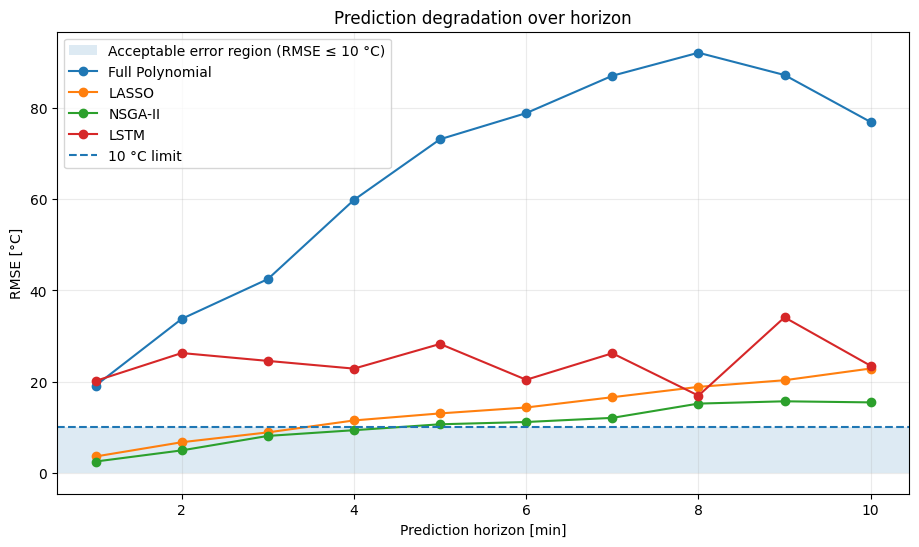

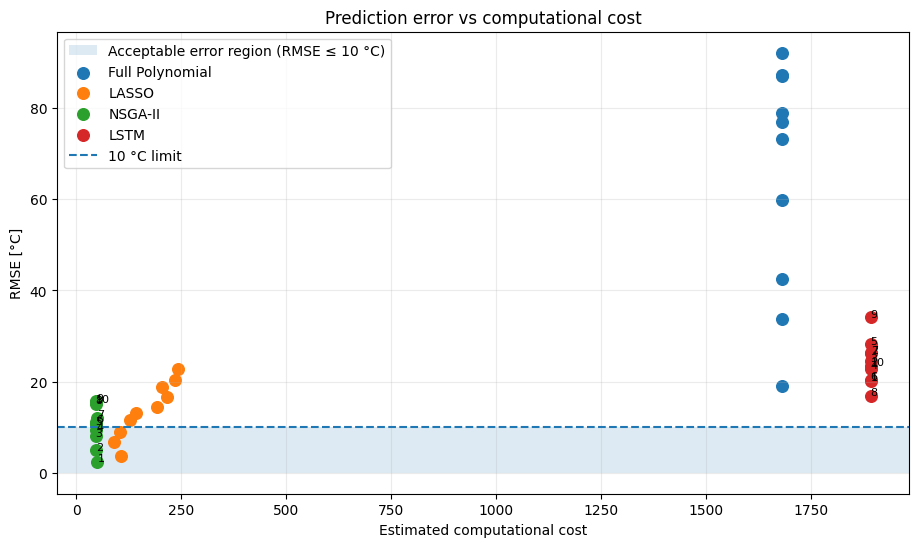

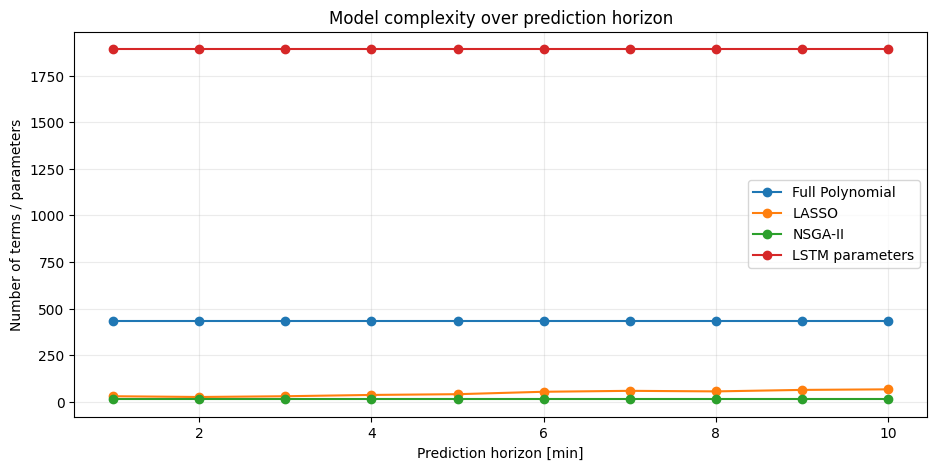

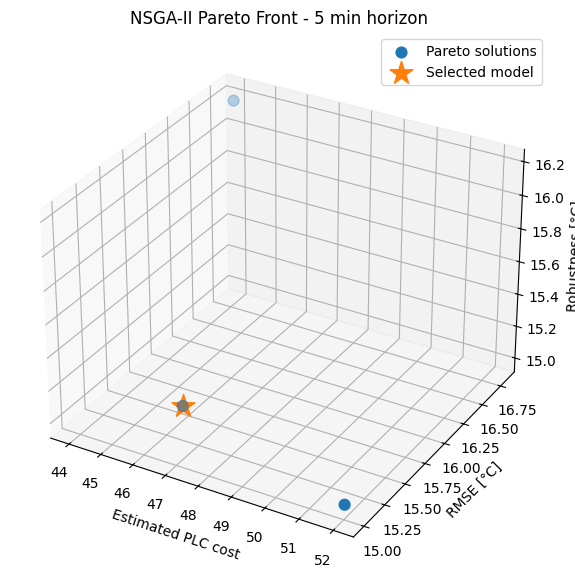

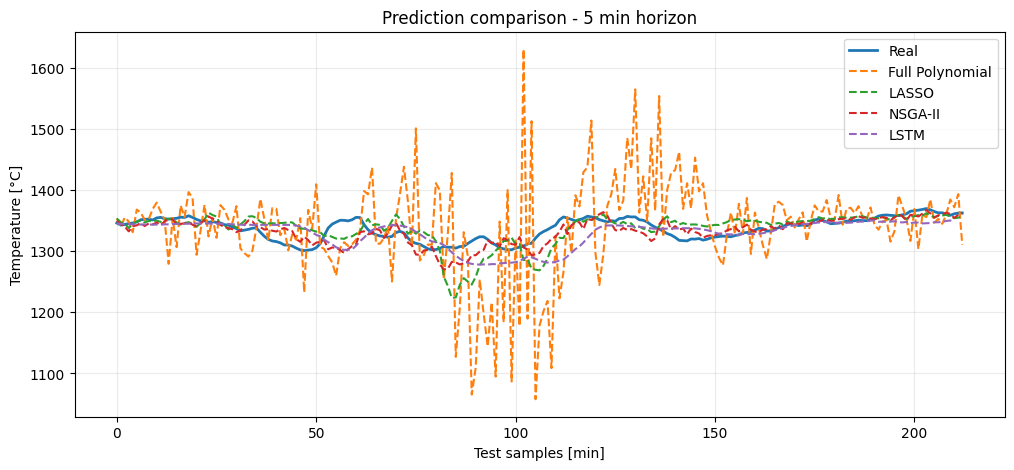

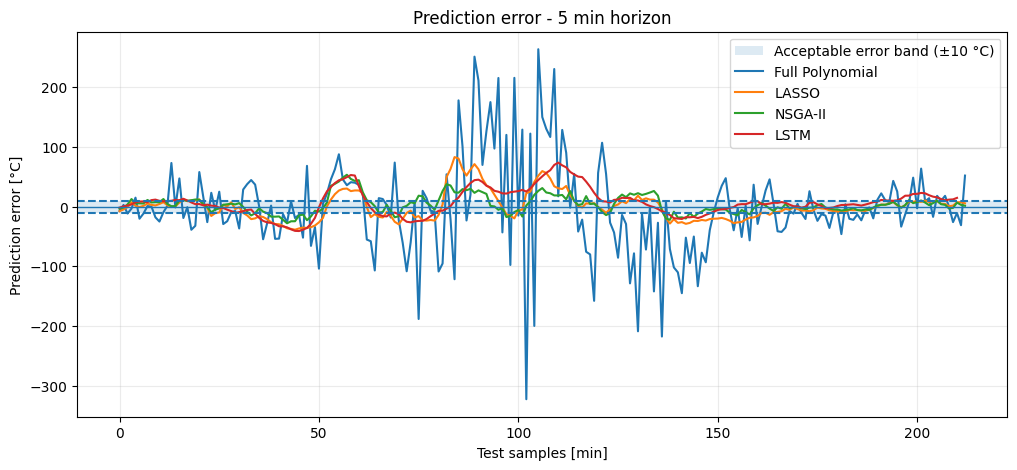


Arquivos gerados:
resultados_full_lasso_nsga_lstm.xlsx
degradacao_horizonte_full_lasso_nsga_lstm.png
erro_vs_custo_full_lasso_nsga_lstm.png
complexidade_full_lasso_nsga_lstm.png
pareto3d_nsga_lstm_comparison.png
previsao_h5_full_lasso_nsga_lstm.png
erro_h5_full_lasso_nsga_lstm.png


In [46]:
# ============================================================
# 5. GRÁFICOS
# ============================================================

# ------------------------------------------------------------
# 5.1 Degradação RMSE x horizonte
# ------------------------------------------------------------

plt.figure(figsize=(11, 6))
plt.axhspan(0, ACCEPTABLE_ERROR, alpha=0.15, label="Acceptable error region (RMSE ≤ 10 °C)")

plt.plot(df_results["H_min"], df_results["Full_RMSE"], marker="o", label="Full Polynomial")
plt.plot(df_results["H_min"], df_results["Lasso_RMSE"], marker="o", label="LASSO")
plt.plot(df_results["H_min"], df_results["NSGA_RMSE"], marker="o", label="NSGA-II")
plt.plot(df_results["H_min"], df_results["LSTM_RMSE"], marker="o", label="LSTM")

plt.axhline(ACCEPTABLE_ERROR, linestyle="--", label="10 °C limit")
plt.xlabel("Prediction horizon [min]")
plt.ylabel("RMSE [°C]")
plt.title("Prediction degradation over horizon")
plt.grid(True, alpha=0.25)
plt.legend()
plt.savefig("degradacao_horizonte_full_lasso_nsga_lstm.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 5.2 Erro x custo computacional
# ------------------------------------------------------------

plt.figure(figsize=(11, 6))
plt.axhspan(0, ACCEPTABLE_ERROR, alpha=0.15, label="Acceptable error region (RMSE ≤ 10 °C)")

plt.scatter(df_results["Full_Custo"], df_results["Full_RMSE"], label="Full Polynomial", s=70)
plt.scatter(df_results["Lasso_Custo"], df_results["Lasso_RMSE"], label="LASSO", s=70)
plt.scatter(df_results["NSGA_Custo"], df_results["NSGA_RMSE"], label="NSGA-II", s=70)
plt.scatter(df_results["LSTM_Custo"], df_results["LSTM_RMSE"], label="LSTM", s=70)

for _, row in df_results.iterrows():
    H = int(row["H_min"])
    plt.annotate(str(H), (row["NSGA_Custo"], row["NSGA_RMSE"]), fontsize=8)
    plt.annotate(str(H), (row["LSTM_Custo"], row["LSTM_RMSE"]), fontsize=8)

plt.axhline(ACCEPTABLE_ERROR, linestyle="--", label="10 °C limit")
plt.xlabel("Estimated computational cost")
plt.ylabel("RMSE [°C]")
plt.title("Prediction error vs computational cost")
plt.grid(True, alpha=0.25)
plt.legend()
plt.savefig("erro_vs_custo_full_lasso_nsga_lstm.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 5.3 Complexidade x horizonte
# ------------------------------------------------------------

plt.figure(figsize=(11, 5))

plt.plot(df_results["H_min"], df_results["Full_Termos"], marker="o", label="Full Polynomial")
plt.plot(df_results["H_min"], df_results["Lasso_Termos"], marker="o", label="LASSO")
plt.plot(df_results["H_min"], df_results["NSGA_Termos"], marker="o", label="NSGA-II")
plt.plot(df_results["H_min"], df_results["LSTM_Termos"], marker="o", label="LSTM parameters")

plt.xlabel("Prediction horizon [min]")
plt.ylabel("Number of terms / parameters")
plt.title("Model complexity over prediction horizon")
plt.grid(True, alpha=0.25)
plt.legend()
plt.savefig("complexidade_full_lasso_nsga_lstm.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 5.4 Pareto 3D NSGA-II para H=5
# ------------------------------------------------------------

H_PARETO = 10
pf = paretos[H_PARETO]

rmse = np.array([p["RMSE"] for p in pf])
cost = np.array([p["COST"] for p in pf])
rob = np.array([p["ROB"] for p in pf])

row5 = df_results[df_results["H_min"] == H_PARETO].iloc[0]

idx_star = np.argmin(
    (rmse - row5["NSGA_RMSE"])**2 +
    (cost - row5["NSGA_Custo"])**2 +
    (rob - row5["NSGA_Robustez"])**2
)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(cost, rmse, rob, s=60, label="Pareto solutions")
ax.scatter(cost[idx_star], rmse[idx_star], rob[idx_star], marker="*", s=300, label="Selected model")

ax.set_xlabel("Estimated PLC cost")
ax.set_ylabel("RMSE [°C]")
ax.set_zlabel("Robustness [°C]")
ax.set_title("NSGA-II Pareto Front - 5 min horizon")
ax.legend()

plt.savefig("pareto3d_nsga_lstm_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 5.5 Previsão H=5
# ------------------------------------------------------------

H_PLOT = 10
pack = predictions[H_PLOT]

n_plot = min(220, len(pack["y_test_narx"]))

plt.figure(figsize=(12, 5))

plt.plot(pack["y_test_narx"][:n_plot], linewidth=2, label="Real")
plt.plot(pack["Full"][:n_plot], linestyle="--", label="Full Polynomial")
plt.plot(pack["Lasso"][:n_plot], linestyle="--", label="LASSO")
plt.plot(pack["NSGA"][:n_plot], linestyle="--", label="NSGA-II")

# LSTM pode ter tamanho diferente devido ao lookback
n_lstm = min(n_plot, len(pack["LSTM"]))
plt.plot(pack["LSTM"][:n_lstm], linestyle="--", label="LSTM")

plt.xlabel("Test samples [min]")
plt.ylabel("Temperature [°C]")
plt.title("Prediction comparison - 5 min horizon")
plt.grid(True, alpha=0.25)
plt.legend()
plt.savefig("previsao_h5_full_lasso_nsga_lstm.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 5.6 Erro H=5
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))
plt.axhspan(-ACCEPTABLE_ERROR, ACCEPTABLE_ERROR, alpha=0.15, label="Acceptable error band (±10 °C)")

err_full = pack["y_test_narx"][:n_plot] - pack["Full"][:n_plot]
err_lasso = pack["y_test_narx"][:n_plot] - pack["Lasso"][:n_plot]
err_nsga = pack["y_test_narx"][:n_plot] - pack["NSGA"][:n_plot]

plt.plot(err_full, label="Full Polynomial")
plt.plot(err_lasso, label="LASSO")
plt.plot(err_nsga, label="NSGA-II")

n_lstm = min(n_plot, len(pack["LSTM"]))
err_lstm = pack["y_test_lstm"][:n_lstm] - pack["LSTM"][:n_lstm]
plt.plot(err_lstm, label="LSTM")

plt.axhline(ACCEPTABLE_ERROR, linestyle="--")
plt.axhline(-ACCEPTABLE_ERROR, linestyle="--")
plt.axhline(0, linewidth=1)

plt.xlabel("Test samples [min]")
plt.ylabel("Prediction error [°C]")
plt.title("Prediction error - 5 min horizon")
plt.grid(True, alpha=0.25)
plt.legend()
plt.savefig("erro_h5_full_lasso_nsga_lstm.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nArquivos gerados:")
print("resultados_full_lasso_nsga_lstm.xlsx")
print("degradacao_horizonte_full_lasso_nsga_lstm.png")
print("erro_vs_custo_full_lasso_nsga_lstm.png")
print("complexidade_full_lasso_nsga_lstm.png")
print("pareto3d_nsga_lstm_comparison.png")
print("previsao_h5_full_lasso_nsga_lstm.png")
print("erro_h5_full_lasso_nsga_lstm.png")